In [ ]:
import torch
import pandas as pd

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
valid_df = pd.read_csv("/content/valid.csv")
test_df = pd.read_csv("/content/test.csv")

In [ ]:
train_df = pd.read_csv("/content/train.csv")
train_df

,title,text,year_month,labels
0,"Denying feud over Russia hacking, Trump vows s...",langley va. washington u. s. president donald ...,2017-01,true
1,Obama Calls To Comfort A Murdered Lawmaker’s ...,picture someone decides one leaders traitor su...,2016-06,fake
2,Cost of modernizing U.S. nuclear weapons to fa...,minot air force base n. d. flat windy expanse ...,2016-09,true
3,THE MOMENT FBI Director James Comey Lost All C...,hillary clinton dogged throughout campaign dec...,2017-05,fake
4,Racist Florida Woman Tells Black People ‘You ...,racist white woman florida surely furious afri...,2016-08,fake
...,...,...,...,...
21522,Hyatt heir Pritzker opens Democratic bid to un...,chicago billionaire investor j. b. pritzker he...,2017-04,true
21523,New Hampshire to test broader appeal of Cruz's...,henniker new hampshire republican presidential...,2016-02,true
21524,Trevor Noah Asks Debbie Wasserman-Schultz If ...,democratic national committee dnc chairwoman d...,2016-04,fake
21525,HILLARY TRIES TO INJECT Social Class And Race ...,maybe hillary hiring someone handle social med...,2016-02,fake


In [ ]:
train_df['labels'].value_counts()

,count
labels,
fake,13781
true,7746


In [ ]:
valid_df['labels'].value_counts()

,count
labels,
true,6722
fake,1655


In [ ]:
test_df['labels'].value_counts()

,count
labels,
true,6723
fake,1655


In [ ]:
train_df['full_text'] = train_df['title'] + " " + train_df['text']
train_df

,title,text,year_month,labels,full_text
0,"Denying feud over Russia hacking, Trump vows s...",langley va. washington u. s. president donald ...,2017-01,true,"Denying feud over Russia hacking, Trump vows s..."
1,Obama Calls To Comfort A Murdered Lawmaker’s ...,picture someone decides one leaders traitor su...,2016-06,fake,Obama Calls To Comfort A Murdered Lawmaker’s ...
2,Cost of modernizing U.S. nuclear weapons to fa...,minot air force base n. d. flat windy expanse ...,2016-09,true,Cost of modernizing U.S. nuclear weapons to fa...
3,THE MOMENT FBI Director James Comey Lost All C...,hillary clinton dogged throughout campaign dec...,2017-05,fake,THE MOMENT FBI Director James Comey Lost All C...
4,Racist Florida Woman Tells Black People ‘You ...,racist white woman florida surely furious afri...,2016-08,fake,Racist Florida Woman Tells Black People ‘You ...
...,...,...,...,...,...
21522,Hyatt heir Pritzker opens Democratic bid to un...,chicago billionaire investor j. b. pritzker he...,2017-04,true,Hyatt heir Pritzker opens Democratic bid to un...
21523,New Hampshire to test broader appeal of Cruz's...,henniker new hampshire republican presidential...,2016-02,true,New Hampshire to test broader appeal of Cruz's...
21524,Trevor Noah Asks Debbie Wasserman-Schultz If ...,democratic national committee dnc chairwoman d...,2016-04,fake,Trevor Noah Asks Debbie Wasserman-Schultz If ...
21525,HILLARY TRIES TO INJECT Social Class And Race ...,maybe hillary hiring someone handle social med...,2016-02,fake,HILLARY TRIES TO INJECT Social Class And Race ...


In [ ]:
valid_df['full_text'] = valid_df['title'] + " " + valid_df['text']
test_df['full_text'] = test_df['title'] + " " + test_df['text']

In [ ]:
train_df['labels'] = train_df['labels'].map({'true':0, 'fake':1})

In [ ]:
valid_df['labels'] = valid_df['labels'].map({'true':0, 'fake':1})
test_df['labels'] = test_df['labels'].map({'true':0, 'fake':1})

In [ ]:
train_df.to_csv("train.csv", index=None)
valid_df.to_csv("valid.csv", index=None)
test_df.to_csv("test.csv", index=None)

In [ ]:
from torch.utils.data import Dataset, DataLoader

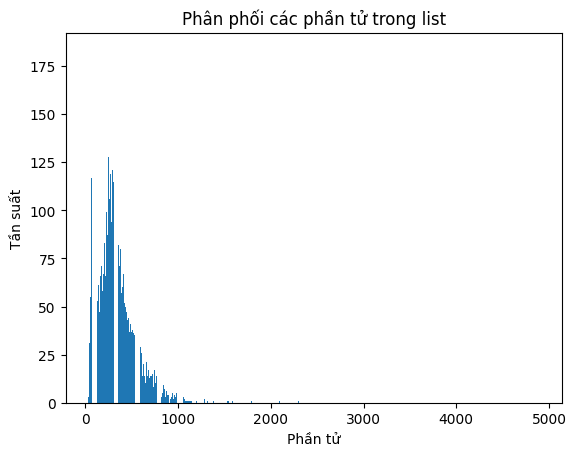

In [ ]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
encoded = [tokenizer.encode(text) for text in test_df['full_text']]
num_tokens = []
for text in encoded:
  num_tokens = np.append(num_tokens, len(text))

plt.hist(num_tokens, bins=len(set(num_tokens)), rwidth=0.8)
plt.xlabel("Phần tử")
plt.ylabel("Tần suất")
plt.title("Phân phối các phần tử trong list")
plt.show()

In [ ]:
class FakeNewDataset(Dataset):
  def __init__(self, csv_path, tokenizer, max_length = 1024, pad_token_id = 50256):
    self.df = pd.read_csv(csv_path)

    self.encoded_texts = [tokenizer.encode(text) for text in self.df['full_text']]

    self.max_length = max_length
    self.encoded_texts = [text[:self.max_length] for text in self.encoded_texts]

    self.encoded_texts = [
      text + [pad_token_id] * (self.max_length - len(text))
      for text in self.encoded_texts
    ]

  def __getitem__(self, index):
    text = self.encoded_texts[index]
    label = self.df.iloc[index]['labels']
    return (torch.tensor(text, dtype=torch.long), torch.tensor(label, dtype=torch.long))

  def __len__(self):
    return len(self.df)


In [ ]:
train_set = FakeNewDataset('/content/train.csv', tokenizer, max_length=512)
valid_set = FakeNewDataset('/content/valid.csv', tokenizer, max_length=512)
test_set = FakeNewDataset('/content/test.csv', tokenizer, max_length=512)

In [ ]:
num_workers = 0
batch_size = 10

train_loader = DataLoader(
    dataset=train_set,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True
)

valid_loader = DataLoader(
    dataset=valid_set,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True
)

test_loader = DataLoader(
    dataset=test_set,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True
)

In [ ]:
for input_batch, target_batch in train_loader:
  pass

print("Input batch dimensions:", input_batch.shape)
print("Label batch dimensions", target_batch.shape)

Input batch dimensions: torch.Size([10, 512])
Label batch dimensions torch.Size([10])


In [ ]:
print(f"{len(train_loader)} training batches")
print(f"{len(valid_loader)} validation batches")
print(f"{len(test_loader)} test batches")

2152 training batches
837 validation batches
837 test batches


In [ ]:
from torch import nn

In [ ]:
class GPT2Model(nn.Module):
  def __init__(self, cfg_map):
    super().__init__()

    # embedding components
    self.emb_layer = nn.Embedding(cfg_map['vocab_size'], cfg_map['emb_dim'])
    self.pos_emb_layer = nn.Embedding(cfg_map['context_length'], cfg_map['emb_dim'])

    # huh
    self.dropout = nn.Dropout(cfg_map['drop_rate'])

    # transformer
    self.trfm_block = nn.Sequential(*[TransformerBlock(cfg_map) for i in range(cfg_map['n_layers'])])

    self.final_norm = LayerNorm(cfg_map['emb_dim'])

    # convert to logits
    self.out_head = nn.Linear(cfg_map['emb_dim'], cfg_map['vocab_size'], bias = False)

  def forward(self, in_idx):
    batch_size, seq_len = in_idx.shape
    tok_embed = self.emb_layer(in_idx)
    pos_embed = self.pos_emb_layer(torch.arange(seq_len, device = in_idx.device))
    x = tok_embed + pos_embed
    x = self.dropout(x)
    x = self.trfm_block(x)
    x = self.final_norm(x)

    logits = self.out_head(x)

    return logits

class TransformerBlock(nn.Module):
  def __init__(self, cfg_map):
    super().__init__()
    self.norm_1 = LayerNorm(cfg_map['emb_dim'])
    self.multihead_attention = MultiheadAttention(cfg_map['emb_dim'], cfg_map['emb_dim'],
                                                  cfg_map['drop_rate'], cfg_map['context_length'],
                                                  cfg_map['n_heads'], cfg_map['qkv_bias'])
    self.dropout = nn.Dropout(cfg_map['drop_rate'])
    self.norm_2 = LayerNorm(cfg_map['emb_dim'])
    self.ffw = FeedForward(cfg_map)
  def forward(self, x):
    shortcut_x  = x
    x = self.norm_1(x)
    x = self.multihead_attention(x)
    x = self.dropout(x)
    x = shortcut_x + x

    shortcut_x = x
    x = self.norm_2(x)
    x = self.ffw(x)
    x = self.dropout(x)
    x = x + shortcut_x
    return x

class LayerNorm(nn.Module):
  def __init__(self, emb_dim, eps=1e-5):
    super().__init__()
    self.epsilon = eps

    # learnable params to tweak the layer norm
    self.scale = nn.Parameter(torch.ones(emb_dim))
    self.shift = nn.Parameter(torch.zeros(emb_dim))

  def forward(self, x):
    mean = torch.mean(x, dim = -1, keepdim = True)
    var = torch.var(x, dim = -1, keepdim = True, correction = False)
    norm_x = (x - mean) / (var + self.epsilon)**0.5
    return self.scale * norm_x + self.shift

class GELULayer(nn.Module):
  def __init__(self):
    super().__init__()

  def forward(self, x):
    return 0.5 * x * (1 + torch.tanh((2/torch.pi)**0.5 * (x + 0.044715 * x**3)))

class FeedForward(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(cfg['emb_dim'], 4 * cfg['emb_dim']), # domain expansion
        GELULayer(), # just gelu for non-linear
        nn.Linear(4 * cfg['emb_dim'], cfg['emb_dim']), # domain contraction
    )

  def forward(self, x):
    return self.layers(x)

class MultiheadAttention(nn.Module):
  def __init__(self, d_in, d_out, drop_out_rate, context_length, num_heads, ena_bias = False):
    super().__init__()

    assert (d_out % num_heads == 0), \
      "d_out must be divisible by num_heads"

    self.d_in = d_in
    self.d_out = d_out
    self.num_heads = num_heads
    self.head_dim = self.d_out // self.num_heads

    self.W_Q = nn.Linear(d_in, d_out, bias = ena_bias)
    self.W_K = nn.Linear(d_in, d_out, bias = ena_bias)
    self.W_V = nn.Linear(d_in, d_out, bias = ena_bias)

    # projection?
    self.out_proj = nn.Linear(d_out, d_out)

    self.drop_out_layer = nn.Dropout(drop_out_rate)
    self.register_buffer('mask', torch.triu(torch.ones(context_length, context_length), diagonal = 1))

  def forward(self, x):

    batch, num_tokens, d_in = x.shape

    queries = self.W_Q(x)
    keys = self.W_K(x)
    values = self.W_V(x)

    queries = queries.view(batch, num_tokens, self.num_heads, self.head_dim)
    keys = keys.view(batch, num_tokens, self.num_heads, self.head_dim)
    values = values.view(batch, num_tokens, self.num_heads, self.head_dim)

    queries = queries.transpose(1,2)
    keys = keys.transpose(1,2)
    values = values.transpose(1,2)

    attention_score = queries @ keys.transpose(2, 3)

    mask_bool = self.mask.bool()[:num_tokens, :num_tokens]
    attention_score.masked_fill_(mask_bool, -torch.inf)
    attention_score = attention_score / self.head_dim**0.5
    attention_weight = torch.softmax(attention_score, dim = -1)
    attention_weight = self.drop_out_layer(attention_weight)

    context_vectors = (attention_weight @ values).transpose(1, 2)

    context_vectors = context_vectors.contiguous().view(batch, num_tokens, self.d_out)

    # combs for learning relationship of head's results
    context_vectors = self.out_proj(context_vectors)

    return context_vectors


In [ ]:
GPT_CONFIG_124M = {
  "vocab_size": 50257, # Vocabulary size
  "context_length": 256, # Context length
  "emb_dim": 768, # Embedding dimension
  "n_heads": 12, # Number of multihead_attentionention heads
  "n_layers": 12, # Number of layers
  "drop_rate": 0.1, # Dropout rate
  "qkv_bias": False # Query-Key-Value bias
}

In [ ]:
def text_to_token_ids(text, tokenizer):
  encoded = tokenizer.encode(text,  allowed_special = {'<|endoftext|>'})
  encoded_tensor = torch.tensor(encoded).unsqueeze(0) # add batch dim
  return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
  # tiktoken only accept integer numpy array, never tensor
  if isinstance(token_ids, torch.Tensor):
      token_ids = token_ids.squeeze().tolist()  # [seq_len]
  return tokenizer.decode(token_ids)

In [ ]:
def generate(model, idx, context_length, maximum_token, temperature = 0.0, topk = None, eos_id = None):
  for i in range(maximum_token):
    # slice the input for acceptable input size (<= context length)
    idx = idx[:, -context_length:]

    with torch.no_grad():
      logits = model(idx)

    last_vector = logits[:, -1, :]

    if topk is not None:
      top_logits, _ = torch.topk(last_vector, topk)

      min_val = top_logits[:, -1]

      last_vector = torch.where(
          last_vector < min_val,
          torch.tensor(float('-inf')).to(last_vector.device),
          last_vector
      )

    if temperature > 0.0: #3
      last_vector = last_vector / temperature
      probs = torch.softmax(last_vector, dim=-1)
      idx_next = torch.multinomial(probs, num_samples=1)
    else:
      idx_next = torch.argmax(last_vector, dim = -1, keepdim = True)

    if idx_next == eos_id:
      break

    idx = torch.cat((idx, idx_next), dim = 1) # (batch, num_token, vocab_size)

  return idx


In [ ]:
CHOOSE_MODEL = "gpt2-small (124M)"
INPUT_PROMPT = "Every effort moves"
BASE_CONFIG = {
  "vocab_size": 50257, #1
  "context_length": 1024, #2
  "drop_rate": 0.0, #3
  "qkv_bias": True #4
}
model_configs = {
  "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
  "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
  "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
  "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

In [ ]:
def assign(left, right):
  a = left.shape
  print(" left ok.")
  b = right.shape
  print(" right ok.")
  if left.shape != right.shape:
      raise ValueError(f"Shape mismatch. Left: {left.shape}, "
                        "Right: {right.shape}"
                        )
  return torch.nn.Parameter(torch.tensor(right))

In [ ]:
import numpy as np

def load_weights_into_gpt(gpt, params):
  # position embedding layer
  gpt.pos_emb_layer.weight = assign(gpt.pos_emb_layer.weight, params['wpe'])
  print("Position embedding done!")

  # token embedding layer
  gpt.emb_layer.weight = assign(gpt.emb_layer.weight, params['wte'])
  print("Token embedding done!")

  # transformer block:
  for b in range(len(params['blocks'])):
    # take the weight from params, split it into Q, K, V
    q_w, k_w, v_w = np.split((params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)

    # load into our instance
    gpt.trfm_block[b].multihead_attention.W_Q.weight = assign(gpt.trfm_block[b].multihead_attention.W_Q.weight, q_w.T)
    gpt.trfm_block[b].multihead_attention.W_K.weight = assign(gpt.trfm_block[b].multihead_attention.W_K.weight, k_w.T)
    gpt.trfm_block[b].multihead_attention.W_V.weight = assign(gpt.trfm_block[b].multihead_attention.W_V.weight, v_w.T)
    print("QKV weight done!")

    # bias for Q, K, V
    q_b, k_b, v_b = np.split((params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
    gpt.trfm_block[b].multihead_attention.W_Q.bias = assign(gpt.trfm_block[b].multihead_attention.W_Q.bias, q_b)
    gpt.trfm_block[b].multihead_attention.W_K.bias = assign(gpt.trfm_block[b].multihead_attention.W_K.bias, k_b)
    gpt.trfm_block[b].multihead_attention.W_V.bias = assign(gpt.trfm_block[b].multihead_attention.W_V.bias, v_b)
    print("QKV bias done!")

    # weight for outer projection
    gpt.trfm_block[b].multihead_attention.out_proj.weight = assign(gpt.trfm_block[b].multihead_attention.out_proj.weight, params["blocks"][b]["attn"]["c_proj"]["w"].T)
    gpt.trfm_block[b].multihead_attention.out_proj.bias = assign(gpt.trfm_block[b].multihead_attention.out_proj.bias, params["blocks"][b]["attn"]["c_proj"]["b"])
    print("Outer projection done!")

    # feed forward
    gpt.trfm_block[b].ffw.layers[0].weight = assign(gpt.trfm_block[b].ffw.layers[0].weight, params["blocks"][b]["mlp"]["c_fc"]["w"].T)
    gpt.trfm_block[b].ffw.layers[0].bias = assign(gpt.trfm_block[b].ffw.layers[0].bias, params["blocks"][b]["mlp"]["c_fc"]["b"])
    gpt.trfm_block[b].ffw.layers[2].weight = assign(gpt.trfm_block[b].ffw.layers[2].weight, params["blocks"][b]["mlp"]["c_proj"]["w"].T)
    gpt.trfm_block[b].ffw.layers[2].bias = assign(gpt.trfm_block[b].ffw.layers[2].bias, params["blocks"][b]["mlp"]["c_proj"]["b"])
    print("Feed forward done!")

    # normalize
    gpt.trfm_block[b].norm_1.scale = assign(gpt.trfm_block[b].norm_1.scale, params["blocks"][b]["ln_1"]["g"])
    gpt.trfm_block[b].norm_1.shift = assign(gpt.trfm_block[b].norm_1.shift, params["blocks"][b]["ln_1"]["b"])
    gpt.trfm_block[b].norm_2.scale = assign(gpt.trfm_block[b].norm_2.scale, params["blocks"][b]["ln_2"]["g"])
    gpt.trfm_block[b].norm_2.shift = assign(gpt.trfm_block[b].norm_2.shift, params["blocks"][b]["ln_2"]["b"])
    print("Norm trf done!")

  # final norm
  gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
  gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
  print("Final norm done!")

  # OG GPT2 reuse the token embedding weight
  gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])
  print("Out head done!")

In [ ]:
import urllib.request
url = (
  "https://raw.githubusercontent.com/rasbt/"
  "LLMs-from-scratch/main/ch05/"
  "01_main-chapter-code/gpt_download.py"
)
filename = url.split('/')[-1]
urllib.request.urlretrieve(url, filename)

('gpt_download.py', <http.client.HTTPMessage at 0x7eeb8aca6a50>)

In [ ]:
from gpt_download import download_and_load_gpt2

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(
  model_size=model_size, models_dir="gpt2"
)
model = GPT2Model(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval()

checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 23.6kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:00<00:00, 2.01MiB/s]
hparams.json: 100%|██████████| 90.0/90.0 [00:00<00:00, 114kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 498M/498M [00:44<00:00, 11.2MiB/s]
model.ckpt.index: 100%|██████████| 5.21k/5.21k [00:00<00:00, 4.91MiB/s]
model.ckpt.meta: 100%|██████████| 471k/471k [00:00<00:00, 1.23MiB/s]
vocab.bpe: 100%|██████████| 456k/456k [00:00<00:00, 1.57MiB/s]


 left ok.
 right ok.
Position embedding done!
 left ok.
 right ok.
Token embedding done!
 left ok.
 right ok.
 left ok.
 right ok.
 left ok.
 right ok.
QKV weight done!
 left ok.
 right ok.
 left ok.
 right ok.
 left ok.
 right ok.
QKV bias done!
 left ok.
 right ok.
 left ok.
 right ok.
Outer projection done!
 left ok.
 right ok.
 left ok.
 right ok.
 left ok.
 right ok.
 left ok.
 right ok.
Feed forward done!
 left ok.
 right ok.
 left ok.
 right ok.
 left ok.
 right ok.
 left ok.
 right ok.
Norm trf done!
 left ok.
 right ok.
 left ok.
 right ok.
 left ok.
 right ok.
QKV weight done!
 left ok.
 right ok.
 left ok.
 right ok.
 left ok.
 right ok.
QKV bias done!
 left ok.
 right ok.
 left ok.
 right ok.
Outer projection done!
 left ok.
 right ok.
 left ok.
 right ok.
 left ok.
 right ok.
 left ok.
 right ok.
Feed forward done!
 left ok.
 right ok.
 left ok.
 right ok.
 left ok.
 right ok.
 left ok.
 right ok.
Norm trf done!
 left ok.
 right ok.
 left ok.
 right ok.
 left ok.
 right ok

GPT2Model(
  (emb_layer): Embedding(50257, 768)
  (pos_emb_layer): Embedding(1024, 768)
  (dropout): Dropout(p=0.0, inplace=False)
  (trfm_block): Sequential(
    (0): TransformerBlock(
      (norm_1): LayerNorm()
      (multihead_attention): MultiheadAttention(
        (W_Q): Linear(in_features=768, out_features=768, bias=True)
        (W_K): Linear(in_features=768, out_features=768, bias=True)
        (W_V): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (drop_out_layer): Dropout(p=0.0, inplace=False)
      )
      (dropout): Dropout(p=0.0, inplace=False)
      (norm_2): LayerNorm()
      (ffw): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELULayer()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
    )
    (1): TransformerBlock(
      (norm_1): LayerNorm()
      (multihead_atte

In [ ]:
torch.manual_seed(42)
start_context = (
"Is the following text 'spam'? Answer with 'yes' or 'no':"
" 'You are a winner you have been specially"
" selected to receive $1000 cash or a $2000 award.'"
)
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate(
  model=model,
  idx=text_to_token_ids(start_context, tokenizer),
  maximum_token=50,
  context_length=GPT_CONFIG_124M["context_length"],
  temperature = 3,
  topk = 5,
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Is the following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have been specially selected to receive $1000 cash or a $2000 award.'


'I have not been selected for any award, prize, or prize application.'<|endoftext|>This is an article to be posted on the official website for Star Citizen's upcoming game. It has been updated with information on what the next game in its


In [ ]:
for param in model.parameters():
    param.requires_grad = False # freeze the model

In [ ]:
# modify the output layer into classification layer
torch.manual_seed(123)
num_classes = 2
model.out_head = torch.nn.Linear(in_features=BASE_CONFIG["emb_dim"], out_features=num_classes)

In [ ]:
# make the params in last trfm block & final norm layer trainable
for param in model.trfm_block[-1].parameters():
  param.requires_grad = True
for param in model.final_norm.parameters():
  param.requires_grad = True

In [ ]:
inputs = tokenizer.encode("Do you have time")
inputs = torch.tensor(inputs).unsqueeze(0)
print("Inputs:", inputs)
print("Inputs dimensions:", inputs.shape)

Inputs: tensor([[5211,  345,  423,  640]])
Inputs dimensions: torch.Size([1, 4])


In [ ]:
with torch.no_grad():
  outputs = model(inputs)
print("Outputs:\n", outputs)
print("Outputs dimensions:", outputs.shape)

Outputs:
 tensor([[[-1.5854,  0.9904],
         [-3.7235,  7.4548],
         [-2.2661,  6.6049],
         [-3.5983,  3.9902]]])
Outputs dimensions: torch.Size([1, 4, 2])


In [ ]:
def calc_accuracy_loader(loader, model, device, num_batches = None):
  model.eval()
  correct_predictions, num_examples = 0, 0
  if num_batches is None:
    num_batches = len(loader)
  else:
    num_batches = min(num_batches, len(loader))

  # we process 1 batch at a time.
  for i, (input_batch, target_batch) in enumerate(loader):
    if i < num_batches:
      input_batch = input_batch.to(device)
      target_batch = target_batch.to(device)

      with torch.no_grad():
        logits = model(input_batch)[:,-1,:] # each batch has multiple examples, that's why we need the first ":"
      predicted_labels = torch.argmax(logits, dim=-1) # turn all the logits into indexes, ex. [3, 1, 2] => [3, 1] ??? maybe
      num_examples += predicted_labels.shape[0]
      correct_predictions += ((predicted_labels == target_batch).sum().item()) # target_batch [3, 1]
    else:
      break

  return correct_predictions / num_examples

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
torch.manual_seed(123)
train_accuracy = calc_accuracy_loader(
  train_loader, model, device, num_batches=5
)
val_accuracy = calc_accuracy_loader(
  valid_loader, model, device, num_batches=5
)
test_accuracy = calc_accuracy_loader(
  test_loader, model, device, num_batches=5
)
print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 62.00%
Validation accuracy: 16.00%
Test accuracy: 24.00%


In [ ]:
def calc_loss_batch(input_batch, target_batch, model, device):
  input_batch = input_batch.to(device)
  target_batch = target_batch.to(device)

  logits = model(input_batch)[:, -1, :]

  loss = torch.nn.functional.cross_entropy(logits, target_batch)

  return loss

In [ ]:
def calc_loss_loader(loader, model, device, num_batches = None):
  total_loss = 0.
  if len(loader) == 0:
    return float("nan")

  elif num_batches is None:
    num_batches = len(loader)
  else:
    num_batches = min(num_batches, len(loader))
  for i, (input_batch, target_batch) in enumerate(loader):
    if i < num_batches:
      loss = calc_loss_batch(input_batch, target_batch, model, device)
      total_loss += loss.item()
    else:
      break
  return total_loss / num_batches

In [ ]:
with torch.no_grad(): #1
  train_loss = calc_loss_loader(
  train_loader, model, device, num_batches=5
  )
val_loss = calc_loss_loader(valid_loader, model, device, num_batches=5)
test_loss = calc_loss_loader(test_loader, model, device, num_batches=5)
print(f"Training loss: {train_loss:.3f}")
print(f"Validation loss: {val_loss:.3f}")
print(f"Test loss: {test_loss:.3f}")

Training loss: 2.621
Validation loss: 4.784
Test loss: 4.340


In [ ]:
def train_classifier_simple(model, device, train_loader,
                       val_loader, eval_iter, train_epochs, eval_freq, optimizer):
  train_losses, val_losses, train_accs, val_accs = [], [], [], []
  examples_seen, global_step = 0, -1
  for epoch in range(train_epochs):
    model.train()
    for (input_batch, target_batch) in train_loader:
      optimizer.zero_grad() # delete the last batch gradient
      loss = calc_loss_batch(input_batch, target_batch, model, device)
      loss.backward()
      optimizer.step()

      examples_seen += input_batch.shape[0]
      global_step += 1

      if global_step % eval_freq == 0: #6
        train_loss, val_loss = evaluate_model(model, train_loader, val_loader, device, eval_iter)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        #track_tokens_seen.append(tokens_seen)
        print(f"Ep {epoch+1} (Step {global_step:06d}): "
              f"Train loss {train_loss:.3f}, "
              f"Val loss {val_loss:.3f}"
        )
    train_acc = calc_accuracy_loader(train_loader, model, device, num_batches = eval_iter)
    val_accuracy = calc_accuracy_loader(
    val_loader, model, device, num_batches=eval_iter
    )
    print(f"Training accuracy: {train_accuracy*100:.2f}% | ", end="")
    print(f"Validation accuracy: {val_accuracy*100:.2f}%")
    train_accs.append(train_accuracy)
    val_accs.append(val_accuracy)

  return train_losses, val_losses, train_accs, val_accs, examples_seen

In [ ]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
  model.eval()
  with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
  model.train()
  return train_loss, val_loss

In [ ]:
import time
start_time = time.time()
torch.manual_seed(123)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)
num_epochs = 5
train_losses, val_losses, train_accs, val_accs, examples_seen = \
train_classifier_simple(
  model = model, train_loader = train_loader, val_loader=valid_loader, optimizer=optimizer, device = device,
  train_epochs=num_epochs, eval_freq=50,
  eval_iter=5
)
end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 1.689, Val loss 4.894
Ep 1 (Step 000050): Train loss 0.971, Val loss 1.298
Ep 1 (Step 000100): Train loss 0.773, Val loss 1.090
Ep 1 (Step 000150): Train loss 0.770, Val loss 0.964
Ep 1 (Step 000200): Train loss 0.710, Val loss 1.015
Ep 1 (Step 000250): Train loss 0.650, Val loss 0.747
Ep 1 (Step 000300): Train loss 0.545, Val loss 1.165
Ep 1 (Step 000350): Train loss 0.651, Val loss 0.892
Ep 1 (Step 000400): Train loss 0.625, Val loss 0.838
Ep 1 (Step 000450): Train loss 0.363, Val loss 0.731
Ep 1 (Step 000500): Train loss 0.207, Val loss 0.805
Ep 1 (Step 000550): Train loss 0.276, Val loss 0.538
